In [1]:
using Base.Threads
println( "Number of threads: ", nthreads() )

include( "../args.jl" )
include( "../model.jl" )
include( "../geom.jl" )

Number of threads: 24
Loaded network.jl class file.
Loaded model.jl class file.
Loaded geom.jl class file.


In [2]:
function agent!(plt, L::defFloat, z::State; scale::defFloat=1.0)
    # Define colors for each state φ ∈ {0,1,2}.
    colors = [:indianred, :cornflowerblue, :olivedrab]

    # Color data based on each agent’s φ value.
    clist = [colors[φ+1] for φ in z.φ]

    # Scale the arrow length for visual clarity.
    u = scale.*z.v.*cos.(z.θ)
    v = scale.*z.v.*sin.(z.θ)

    # Add direction arrows.
    quiver!( plt, z.x, z.y; quiver=(u, v), color=:gray68, lw=1.5, arrow=true )

    # Plot positions with state colors.
    scatter!( plt, z.x, z.y; color=clist, markersize=4, markerstrokewidth=1 )

    # Adjust the plot dimensions.
    plot!( plt; xlims=(0,L), ylims=(0,L), legend=false, aspect_ratio=:equal )
    return plt
end

@userplot AgentSim
@recipe function f(as::AgentSim)
    # Unpack data.
    L, t, z, δt = as.args

    # Set plot variables.
    seriestype := :scatter
    aspect_ratio := 1

    # Color by state.
    colors = [:indianred, :cornflowerblue, :olivedrab]
    clist = [colors[φ+1] for φ in z[t].φ]
    seriescolor := clist

    # Plot settings.
    xlims := (0,L)
    ylims := (0,L)
    size := (300,300)
    legend := false

    title := latexstring( "t=$(round( defInt, δt*t ))" )
    titlelocation := :left

    dpi := 100

    # Return scatter data.
    return z[t].x, z[t].y
end

function creategif(L::defFloat, tlist::Union{UnitRange{Int64},Vector{defInt}}, zlist::Vector{State};
    T::defInt=length( tlist ), δt::defFloat=0.01, step::defInt=1, every::defInt=1)
    return @animate for t in tlist[1:step:T]
        agentsim( L, t, zlist, δt )
    end every every
end

creategif (generic function with 1 method)

In [3]:
# System parameters.
μ = 1.0
N = defInt( 100 )
L = √(N/μ)

# Case and data folder.
ξ = 0.1
case = "../data/results/case-0/"
folder = case*"N-$(N)/mu-$(round( μ, digits=3 ))_xi-$(round( ξ, digits=5 ))/"

# Import parameters from simulated data.
scale = loadscale( folder*"sim-scale.json" )
params = adjparams( loadparams( folder*"sim-params.json" ); s=10.0 )
nondim = Nondim( params; scale=scale )
println( "   dim. parameters: ", params )
println( "nondim. parameters: ", nondim )

# Time-step length.
δt = Δt;

   dim. parameters: Params(1.0, 0.1, 0.1, 0.002, 75.0, 0.1, 0.5, 0.0, 0.5, 0.25, 10.0, 1.0, 0.7853981633974483, LogNormal{Float64}(μ=-2.4141568686511503, σ=0.47238072707743883), Truncated(Laplace{Float64}(μ=0.0, θ=0.5); lower=-3.141592653589793, upper=3.141592653589793))
nondim. parameters: Nondim(0.1, 0.010000000000000002, 0.010000000000000002, 0.0002, 750.0, 1.0, 0.5, 0.0, 0.5, 0.25, 0.5623413251903491, 1.0, 0.7853981633974483, LogNormal{Float64}(μ=-0.11157177565710488, σ=0.47238072707743883), Truncated(Laplace{Float64}(μ=0.0, θ=0.5); lower=-3.141592653589793, upper=3.141592653589793))


In [4]:
# Run simulation under each environment parameter.
T = 800;  M = 10
Nt = round( defInt, T/δt );  tlist = 1:Nt
nt = round( defInt, 1/(2*δt*scale.T) );  tsave = Set( 1:nt:Nt );

# Frequency of adjacency calculation.
δt̂ = round( defInt, 0.1/δt )
println( "δt̂ = $(δt̂)" )

δt̂ = 1


In [5]:
# Initialize list and run optimization.
xdata = [Matrix{defFloat}( undef, length( tsave ) + 1, 3 ) for _ ∈ 1:M]
zdata = Matrix{State}( undef, M, Nt + 1 )
@threads for m ∈ 1:M
    # Initialize agent states.
    z = initialstate( N, L; A=1 )
    ẑ = copystate( z )
    zdata[m,1] = copystate( ẑ )

    # Initialize adjacency and saved state.
    A = proximity( N, L, nondim.r, nondim.α, z.x, z.y, z.θ )
    xdata[m][1,:] = statecomposition( N, ẑ )

    # Run simulation.
    t̂ = 2
    for t ∈ tlist

        # Update the adjacency matrix.
        (t % δt̂) == 0 && (A = proximity( N, L, nondim.r, nondim.α, z.x, z.y, z.θ ))

        # Step simulation.
        step!( N, L, nondim, z, ẑ; A=A, δt=δt )
        zdata[m,t+1] = copystate( ẑ )

        # Save state if in appropriate subset.
        t ∈ tsave && (xdata[m][t̂,:] = statecomposition( N, ẑ ); t̂ += 1)

        # Swap contents.
        tmp = z;  z = ẑ;  ẑ = tmp
    end
end

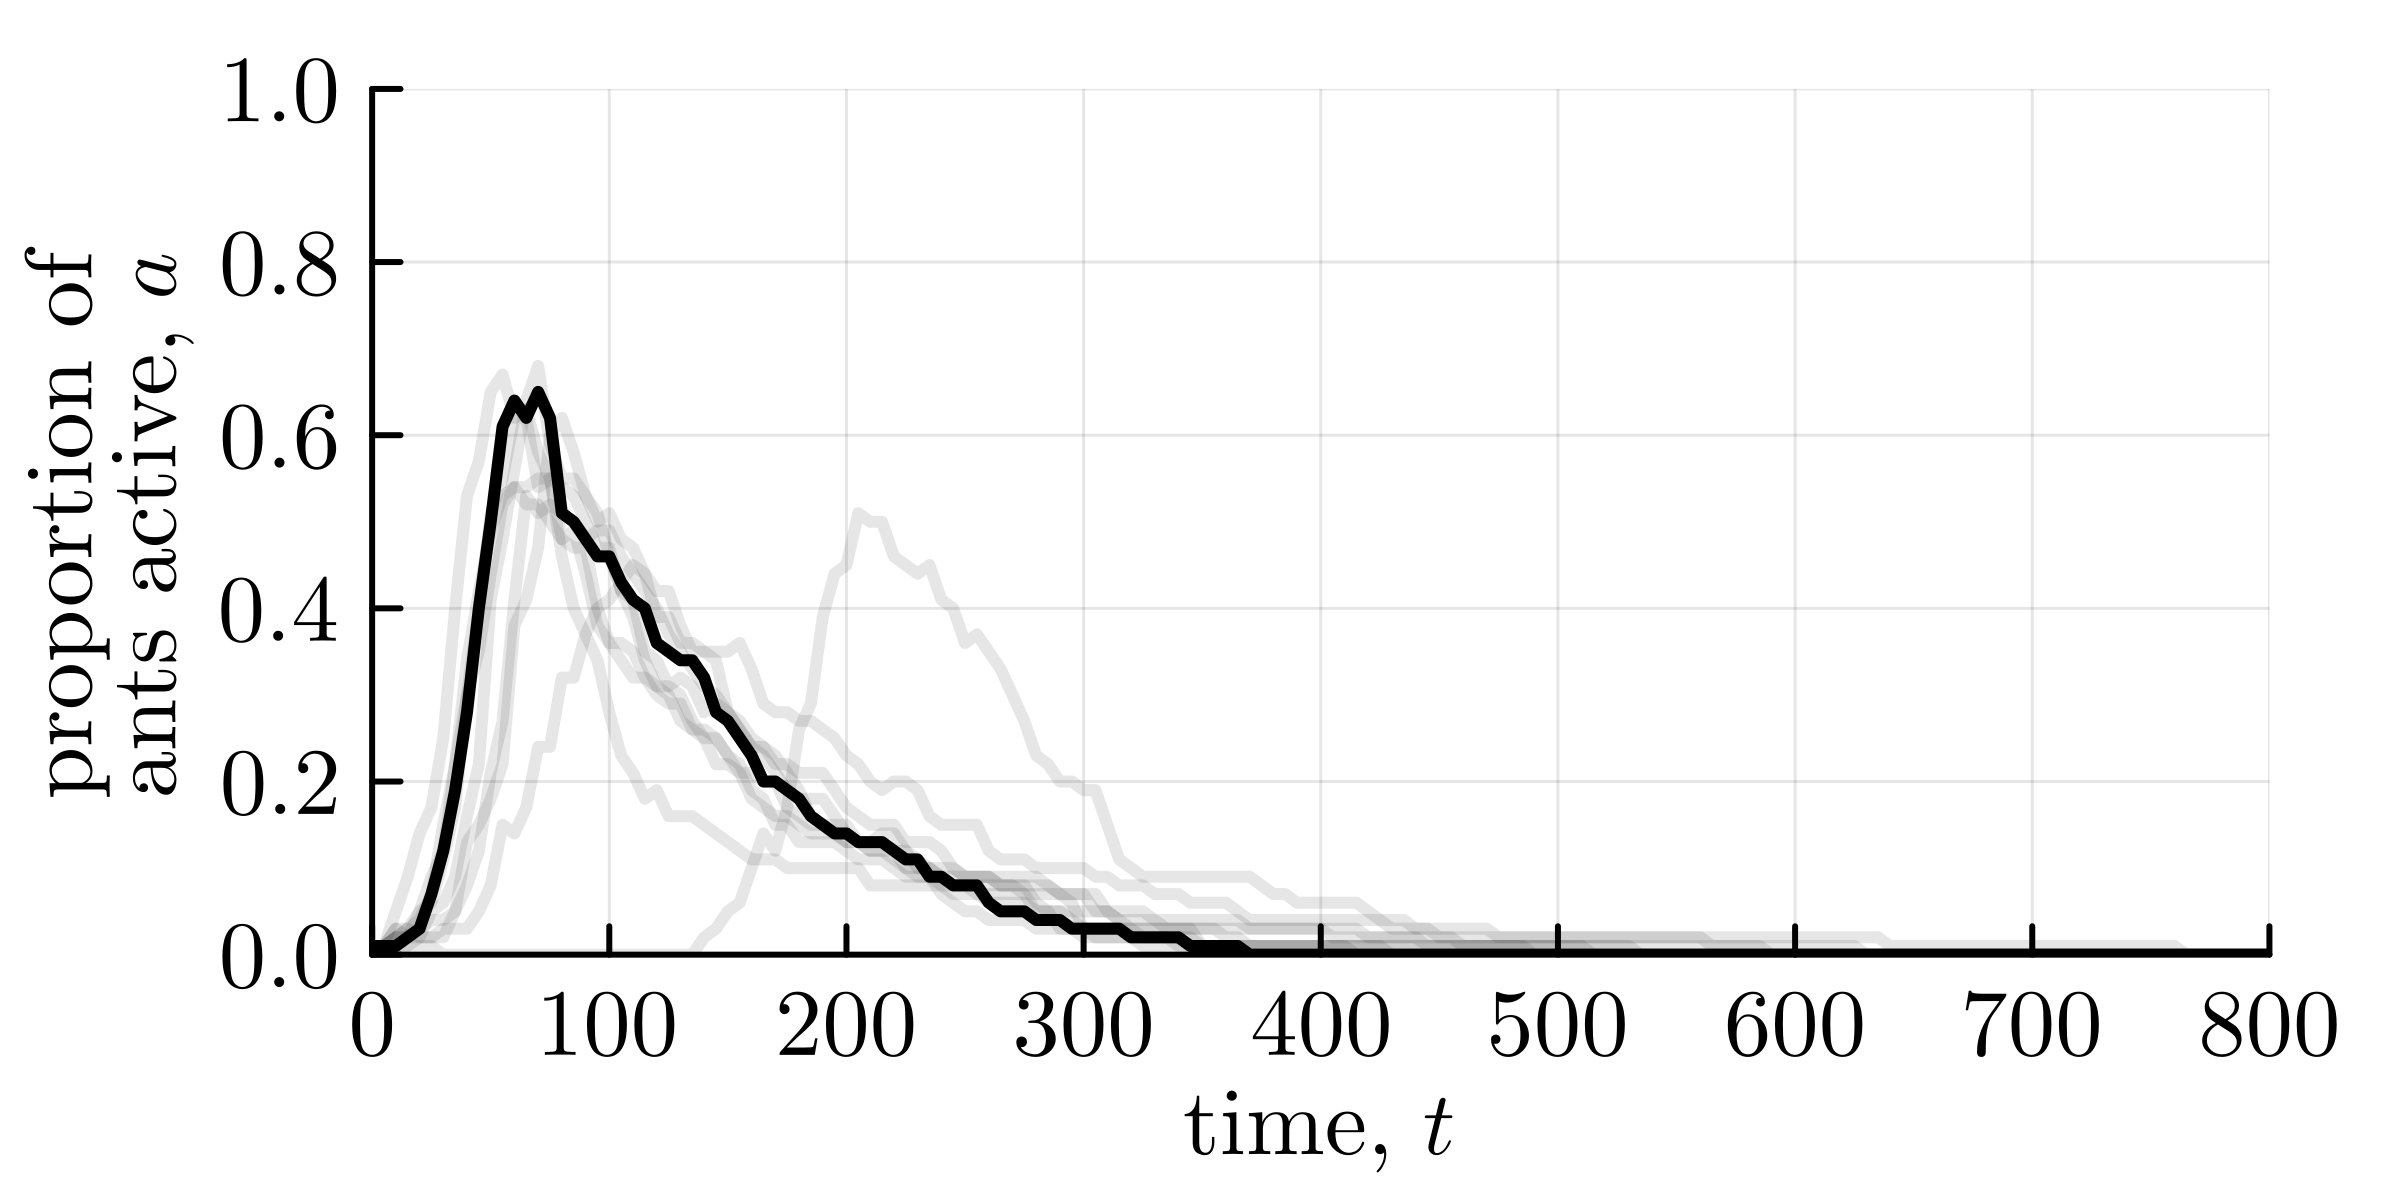

In [6]:
# Plot the mean activity deries for each duration value.
plt = plot( size=(400,200), xformatter=:plain, dpi=600 )
plot!( plt; right_margin=10pt )

m̂ = 1
for m ∈ 1:M
    alist = xdata[m][:,1]
    alpha = m == m̂ ? 1 : 1/10
    plot!( plt, δt*(0:nt:Nt), alist; color=:black, alpha=alpha, lw=2, label="" )
end

plot!( plt; xlims=(0,T), xticks=0:100:T, xlabel="time, "*L"t" )
plot!( plt; ylims=(0,1), ylabel="proportion of\nants active, "*L"a" )

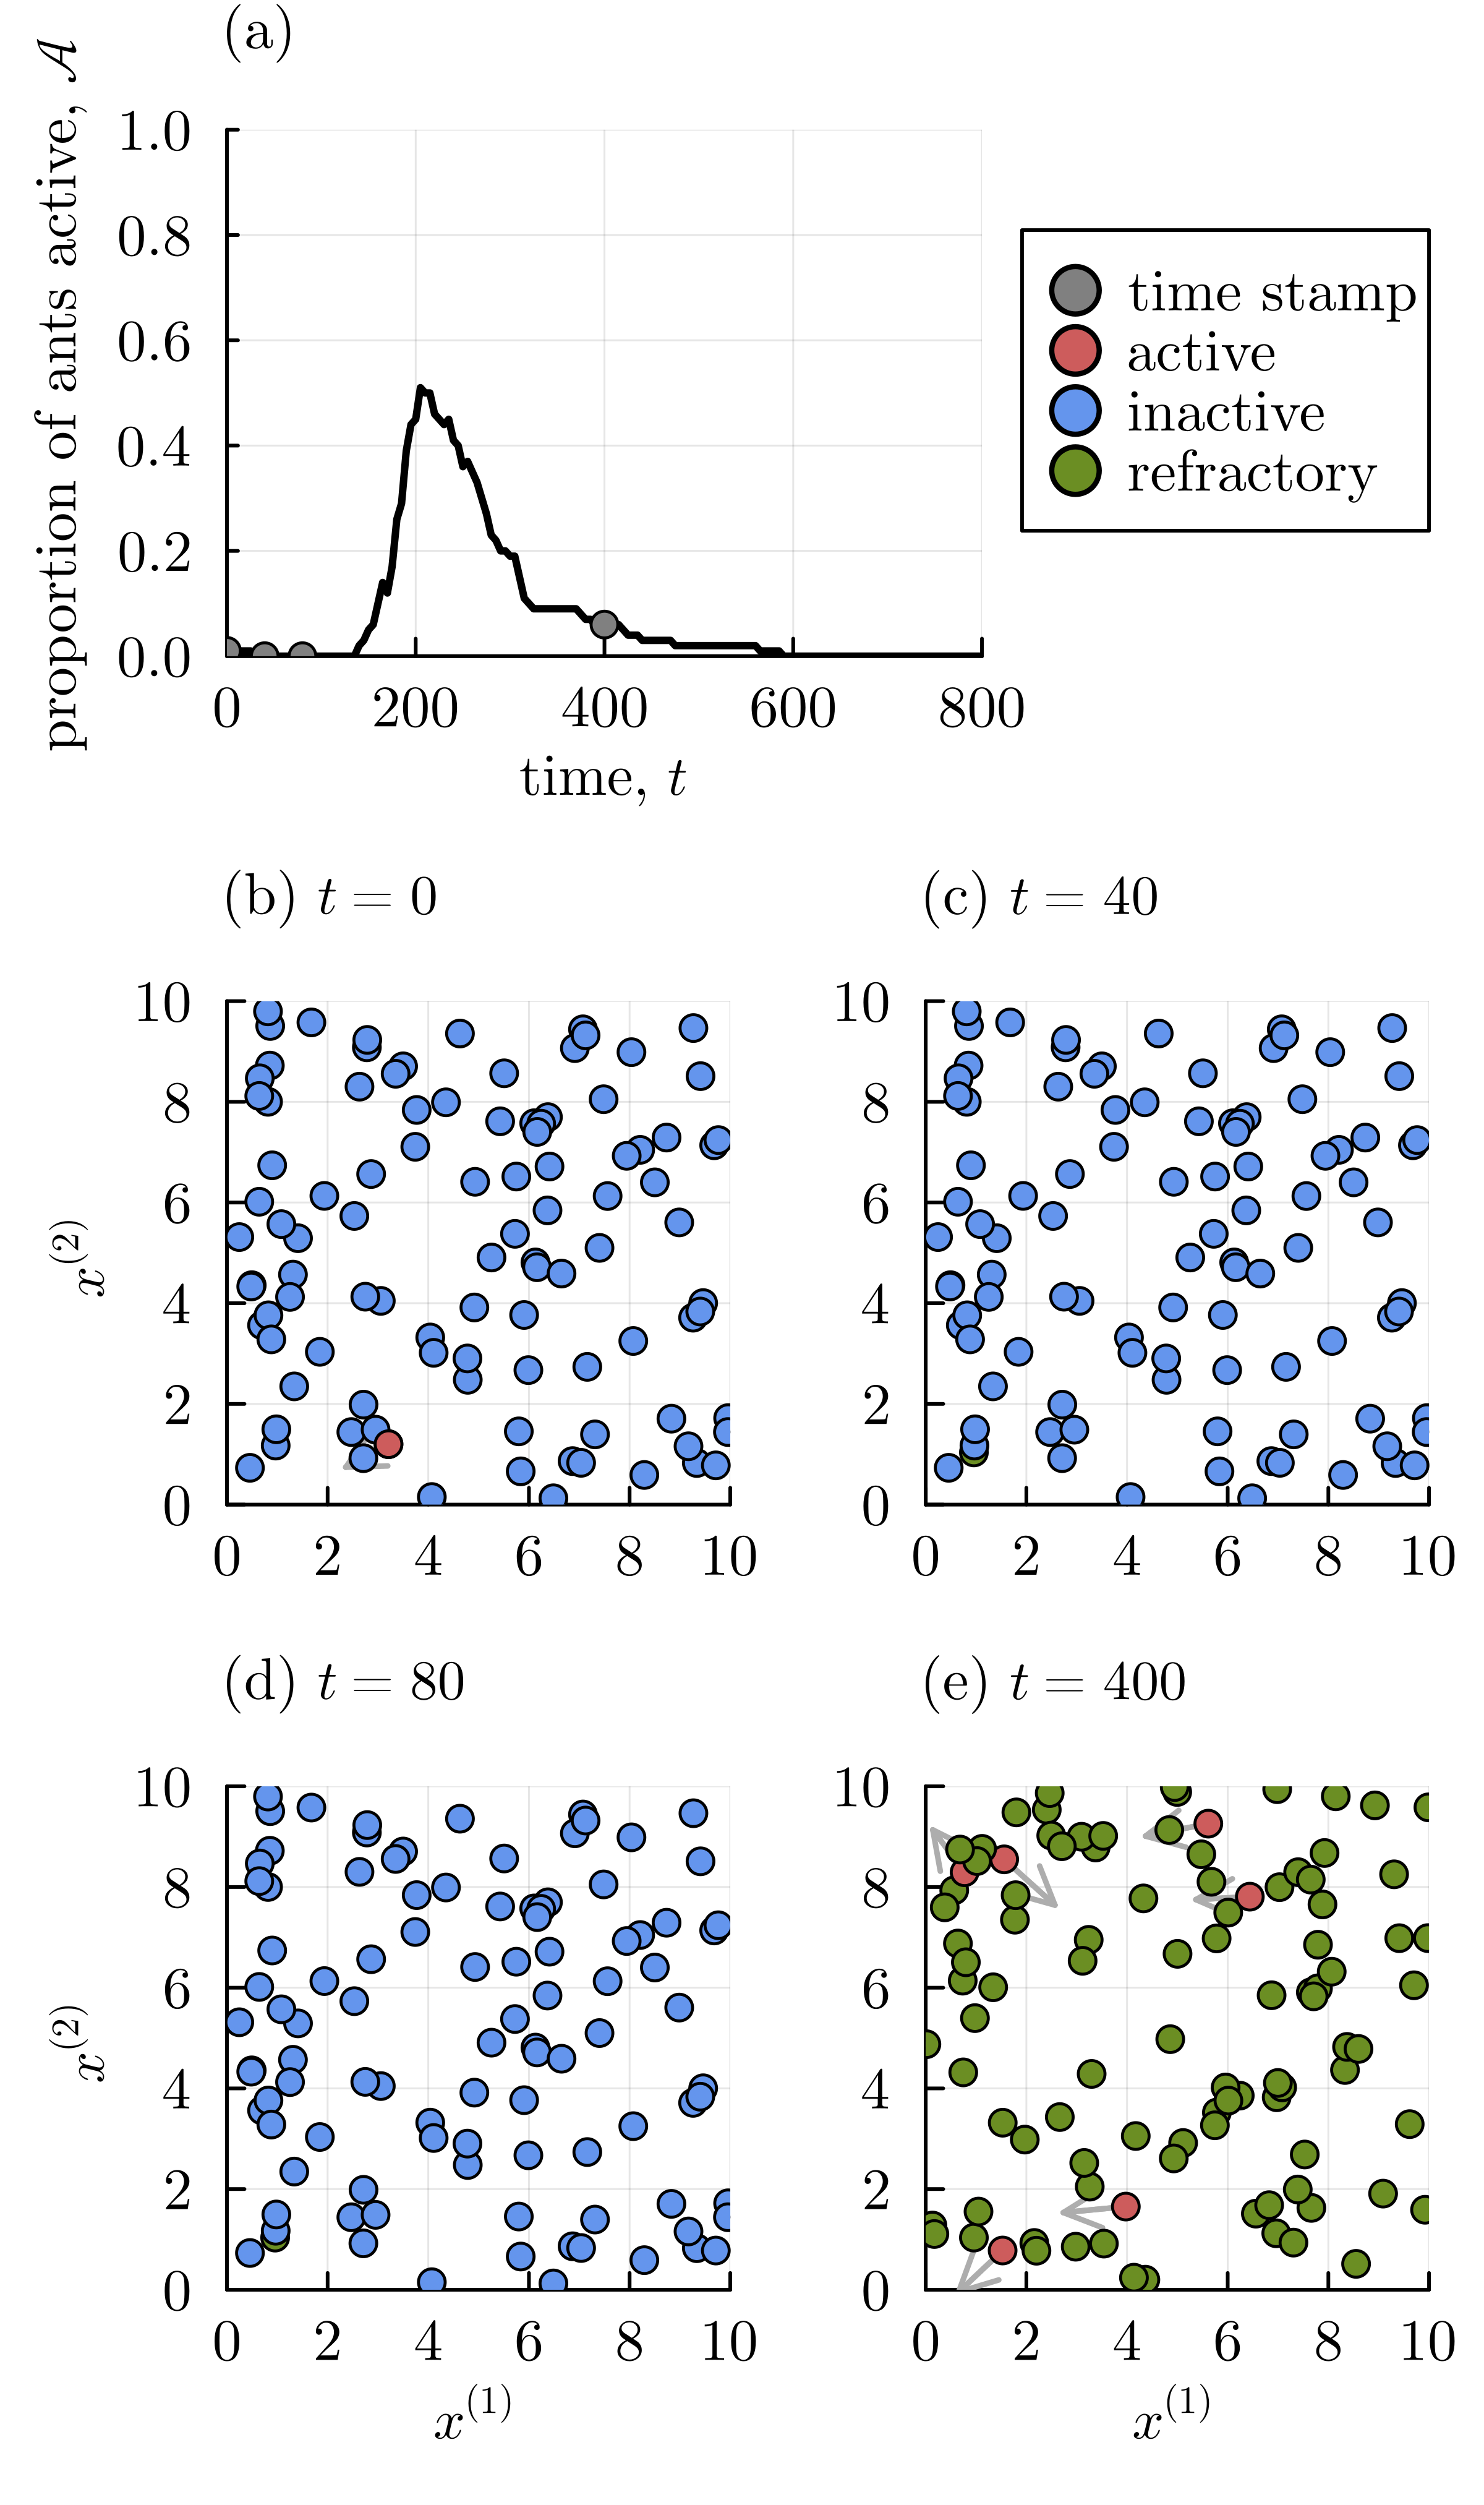

In [7]:
ι = 1  # ID of first-mover.
K = 4;  tplot = [0.25, 40.0, 80.0, 400.0]
layout = @layout( [a; [b c]; [d e]] )
labellist = ["(a)", "(b)", "(c)", "(d)", "(e)"]

# Plot the state composition for identified time-steps.
w = 200;  h = 225
plt = plot( layout=layout, size=(2*w,3*h), xformatter=:plain, dpi=600 )
plot!( plt; left_margin=10pt, bottom_margin=0pt )

# Plot the agent positions over time.
m̂ = 8
for k ∈ 1:K
    # Plot the agents and add title.
    t = round( defInt, tplot[k]/δt+1 )
    agent!( plt[k+1], L, zdata[m̂,t]; scale=2.0 )
    title!( plt[k+1], labellist[k+1]*" "*latexstring("t=$(round( defInt, δt*t ))");
        title_position=:left )

    # Label axes.
    k%2 != 0 && plot!( plt[k+1], ylabel=L"x^{(2)}" )
    k > 2 && plot!( plt[k+1], xlabel=L"x^{(1)}" )

    if k == 1
        scatter!( plt[k+1], [zdata[m̂,t].x[ι]], [zdata[m̂,t].y[ι]]; color=:indianred )
    end
end

# Plot the time-series of the burst with reference stamps.
t̂plot = round.( defInt, 2tplot*scale.T ) .+ 1
t̂list = collect( δt*(0:nt:Nt) );  alist = xdata[m̂][:,1]
plot!( plt[1], t̂list, alist; color=:black, lw=2, label="" )
scatter!( plt[1], t̂list[t̂plot], alist[t̂plot]; color=:gray, label="time stamp" )

scatter!( plt[1], [-1], [-1]; color=:indianred, markersize=4, label="active" )
scatter!( plt[1], [-1], [-1]; color=:cornflowerblue, markersize=4, label="inactive" )
scatter!( plt[1], [-1], [-1]; color=:olivedrab, markersize=4, label="refractory" )
# quiver!( plt[1], [0], [0]; quiver=([1],[1]), color=:black, lw=1.5, label="Test." )

plot!( plt[1]; xlims=(0,T), xticks=0:T/4:T, xlabel="time, "*L"t" )
plot!( plt[1]; ylims=(0,1), ylabel="proportion of ants active, "*L"\mathcal{A}" )
title!( plt[1], labellist[1]; title_position=:left, legend=:outerright )

# saveplot( plt, figurefolder*"burst-demonstration_N-$(N).png" )

┌ Info: Saved animation to /home/michaelnaps/prog/temp/nest-level-synchronization/figures/example-simulation_N-100.gif
└ @ Plots /home/michaelnaps/.julia/packages/Plots/MR7sb/src/animation.jl:156


Plots.AnimatedGif("/home/michaelnaps/prog/temp/nest-level-synchronization/figures/example-simulation_N-100.gif")
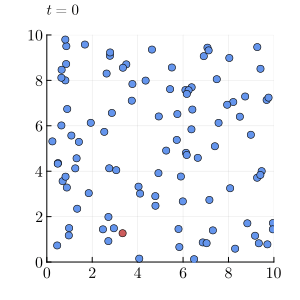

In [8]:
# Create gif from simulation data.
gvar = creategif( L, tlist[1:4000], zdata[m̂,:]; δt=δt, step=5 )
gif( gvar, "../figures/example-simulation_N-$(N).gif" )